# Insurance Claims Fraud Detection Analysis

## Objective
To analyze insurance claims data and identify patterns that indicate potential fraud using Python-based data analysis.

## Dataset
Synthetic dataset simulating real-world insurance claim scenarios including claim amount, reporting lag, vehicle age, and fraud indicators.

## Workflow

1. Data Loading  
2. Data Cleaning  
3. Feature Engineering  
4. Fraud Logic Creation  
5. Data Realism Adjustment  
6. Analysis & Visualization  
7. Final Summary & Recommendations

### 1. Data Loading

In [ ]:
import pandas as pd

df = pd.read_csv('claims_data_v2.csv')

df.head()

,Claim_Number,Policy_Number,Customer_ID,Vehicle_Age,IDV,Claim_Amount,Loss_Date,Intimation_Date,Claim_Cause,Garage_ID,Location
0,CLM0001,POL235,CUST475,4,548964.80,325505.184061,2024-10-14 21:41:08,2024-10-17 21:41:08,Minor Accident,GAR044,Chennai
1,CLM0002,POL113,CUST201,9,332245.65,148225.002781,2024-05-05 06:06:44,2024-05-05 06:06:44,Flood Damage,GAR010,Coimbatore
2,CLM0003,POL275,CUST365,10,393977.00,291883.422955,2023-08-25 14:20:03,2023-08-25 14:20:03,Major Accident,GAR014,Bangalore
3,CLM0004,POL018,CUST075,8,337347.00,217288.052998,2024-05-31 15:44:32,2024-06-01 15:44:32,Major Accident,GAR039,Coimbatore
4,CLM0005,POL387,CUST622,5,547510.50,429122.473572,2023-05-22 10:54:04,2023-05-29 10:54:04,Theft,GAR035,Coimbatore


### 2. Data Cleaning

In [ ]:
df.isnull().sum()

df['Loss_Date'] = pd.to_datetime(df['Loss_Date'])
df['Intimation_Date'] = pd.to_datetime(df['Intimation_Date'])

# Create Reporting Lag (important feature)
df['Reporting_Lag'] = (df['Intimation_Date'] - df['Loss_Date']).dt.days

df.describe()

,Vehicle_Age,IDV,Claim_Amount,Loss_Date,Intimation_Date,Reporting_Lag
count,1500.000000,1500.000000,1500.000000,1500,1500,1500.000000
mean,6.987333,424035.991033,275336.462800,2023-12-25 21:05:27.172000,2023-12-30 04:41:27.172000,4.316667
min,0.000000,91102.800000,39551.408961,2023-01-01 13:48:52,2023-01-03 13:48:52,0.000000
25%,3.750000,267262.425000,159490.826147,2023-06-28 20:47:30.500000,2023-07-04 18:36:54.250000,2.000000
50%,7.000000,380336.500000,235485.409942,2023-12-27 21:49:03,2023-12-30 14:30:47.500000,4.000000
75%,11.000000,560174.837500,350704.155021,2024-06-22 01:34:53.750000,2024-06-26 07:14:51.500000,7.000000
max,14.000000,994996.000000,974671.709883,2024-12-30 22:40:32,2025-01-06 22:40:32,9.000000
std,4.259178,196888.876812,161333.365846,NaN,NaN,2.876440


### 3. Feature Engineering

In [ ]:
df['Claim_Percentage'] = df['Claim_Amount'] / df['Claim_Amount'].max()

# High Claim Indicator: Flags unusually large claims (top 25%) often linked to fraud
df['High_Claim'] = df['Claim_Amount'] > df['Claim_Amount'].quantile(0.75)

# Vehicle Age Risk: Older vehicles tend to have higher probability of suspicious claims
df['Old_Vehicle'] = df['Vehicle_Age'] > 10

# Late Reporting Behavior: Delayed claim reporting is a strong fraud signal
df['Late_Reporting'] = df['Reporting_Lag'] > 7

### 4. Fraud Logic

In [ ]:
# Composite Fraud Score: Weighted model combining multiple behavioral risk indicators
df['Fraud_Score'] = (
    df['High_Claim'].astype(int) * 2 +
    df['Late_Reporting'].astype(int) * 2 +
    df['Old_Vehicle'].astype(int) * 1
)

# Fraud Classification Threshold: Claims with elevated combined risk are flagged
df['Final_Fraud_Flag'] = df['Fraud_Score'] >= 3

In [5]:
df['Claim_Amount'] = df['Claim_Amount'].fillna(df['Claim_Amount'].median())
df['Claim_Cause'] = df['Claim_Cause'].fillna('Unknown')

In [6]:
df['Loss_Date'] = pd.to_datetime(df['Loss_Date'])
df['Intimation_Date'] = pd.to_datetime(df['Intimation_Date'])

df['Reporting_Lag'] = (df['Intimation_Date'] - df['Loss_Date']).dt.days
df['Claim_Percentage'] = df['Claim_Amount'] / df['IDV']

claim_counts = df.groupby('Policy_Number')['Claim_Number'].count()
df['Claim_Frequency'] = df['Policy_Number'].map(claim_counts)

In [7]:
df['Fast_Claim_Flag'] = (
    (df['Reporting_Lag'] <= 1) &
    (df['Claim_Percentage'] > 0.9)
)

df['Late_Reporting_Flag'] = df['Reporting_Lag'] > 2

df['Multiple_Claims_Flag'] = (
    (df['Claim_Frequency'] > 1) &
    (df['Vehicle_Age'] > 5)
)

df['High_Claim_Flag'] = df['Claim_Percentage'] > 0.8

df['Total_Loss_Flag'] = (
    (df['Vehicle_Age'] > 7) &
    (df['Claim_Percentage'] > 0.9) &
    (df['Claim_Cause'].isin(['Fire', 'Flood Damage']))
)

garage_counts = df.groupby('Garage_ID')['Claim_Number'].count()
df['High_Garage_Claims'] = df['Garage_ID'].map(garage_counts) > 30

df['Cluster_Fraud_Flag'] = df['High_Garage_Claims']

In [8]:
df['Fraud_Score'] = (
    df['Late_Reporting_Flag'].astype(int) +
    df['Multiple_Claims_Flag'].astype(int) +
    df['High_Claim_Flag'].astype(int) +
    df['Total_Loss_Flag'].astype(int) +
    df['Cluster_Fraud_Flag'].astype(int) +
    df['Fast_Claim_Flag'].astype(int)
)

df['Final_Fraud_Flag'] = df['Fraud_Score'] >= 2

### 5. Data Realism Adjustment

**Observation:**
The dataset showed overly clean and deterministic fraud patterns due to rule-based labeling.

**Improvement:**
To better simulate real-world uncertainty, a small amount of controlled variation (noise) was introduced into the fraud labels.

**Note:**
All analyses below are recomputed after this adjustment.

After introducing controlled noise into the fraud labels, the dataset was re-segmented into fraud and non-fraud groups to ensure all subsequent analyses reflect the updated classification.

In [ ]:
import numpy as np

# Controlled Noise Injection: Simulates real-world misclassification in fraud detection systems
np.random.seed(42)

noise_ratio = 0.05

noise_indices = df.sample(frac=noise_ratio).index

# Introduce label uncertainty to mimic imperfect fraud detection environments
df.loc[noise_indices, 'Final_Fraud_Flag'] = ~df.loc[noise_indices, 'Final_Fraud_Flag']

# Re-segmentation: Update fraud and non-fraud datasets after noise introduction
fraud_df = df[df['Final_Fraud_Flag'] == True]
non_fraud_df = df[df['Final_Fraud_Flag'] == False]

### 6. Analysis & Visualization

In [18]:
df['Final_Fraud_Flag'].value_counts()

Final_Fraud_Flag
True     1024
False     476
Name: count, dtype: int64

In [19]:
cols = ['Claim_Amount', 'Claim_Percentage', 'Reporting_Lag', 'Vehicle_Age', 'Fraud_Score']
df[cols].describe()
df[['Fraud_Score','Final_Fraud_Flag']].head()

,Fraud_Score,Final_Fraud_Flag
0,2,True
1,2,True
2,2,True
3,2,True
4,1,False


**Chart 1: Distribution of Claim Amounts and High-Value Risk Segments**

**Goal:** Understand how claim amounts are distributed and identify high-value claims that may indicate fraud risk.

**Chart Type:** Histogram

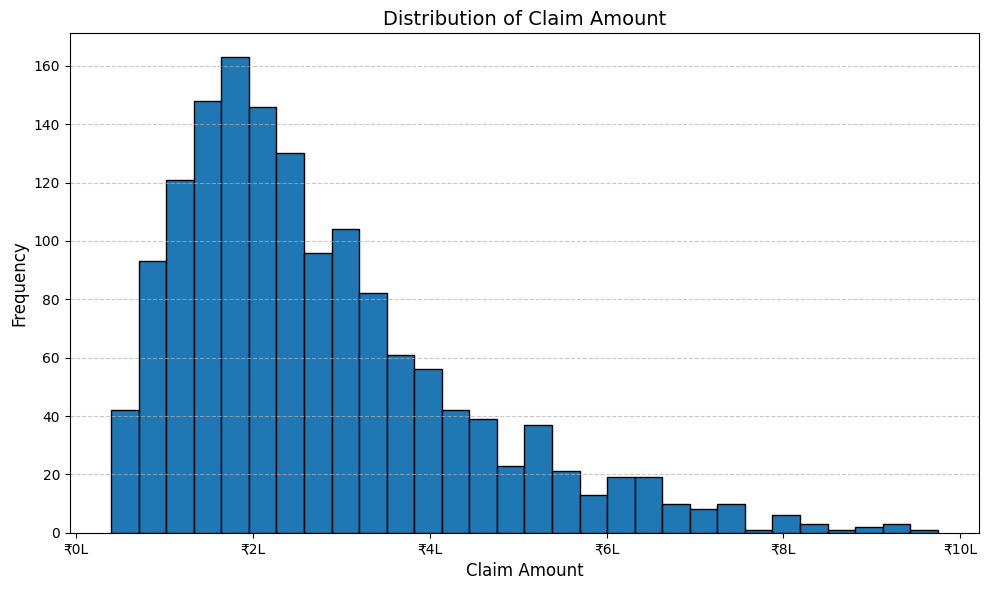

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(10,6))  

plt.hist(df['Claim_Amount'], bins=30, edgecolor='black')

plt.title('Distribution of Claim Amount', fontsize=14)
plt.xlabel('Claim Amount', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)  
plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'₹{x/100000:.0f}L')
)

plt.tight_layout()
plt.show()

**Insight:**
The distribution of claim amounts is right-skewed, with the majority of claims concentrated between ₹1L–₹4L.

A small number of high-value claims extend beyond ₹8L, forming a long tail. These high-value claims are relatively rare but financially significant.

Such extreme claims are potential fraud indicators, as unusually high payouts may involve exaggerated or suspicious claims requiring deeper investigation.  

***Chart 2: Comparitive Analysis of Claim Amount Distribution Between Fraudulent and Non-Fraudulent Claims***

**Goal:** To compare the distribution of claim amounts between fraudulent and non-fraudulent claims and identify whether claim amount can act as a distinguishing factor for fraud detection.

**Chart Type:** KDE Plot (Kernel Density Estimation)


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

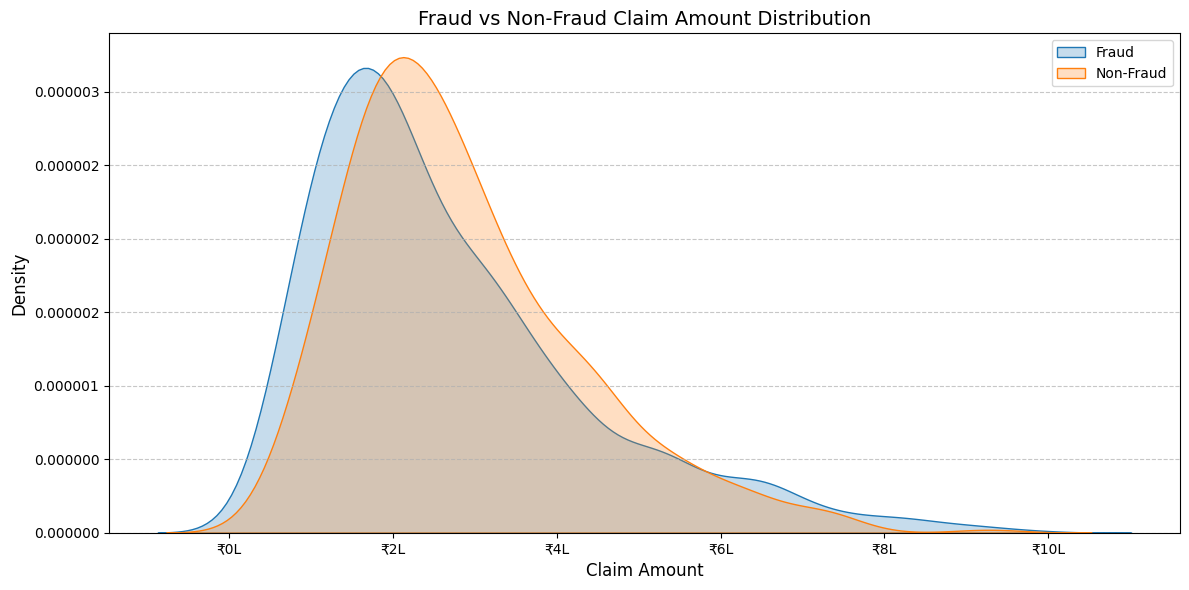

In [22]:
plt.figure(figsize=(12,6))

sns.kdeplot(fraud_df['Claim_Amount'], label='Fraud', fill=True)
sns.kdeplot(non_fraud_df['Claim_Amount'], label='Non-Fraud', fill=True)

plt.title('Fraud vs Non-Fraud Claim Amount Distribution', fontsize=14)
plt.xlabel('Claim Amount', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
import matplotlib.ticker as mticker

plt.gca().xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'₹{x/100000:.0f}L')
)
import matplotlib.ticker as mticker

plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f'{y:.6f}')
)
plt.tight_layout()
plt.show()

**Insight:** Fraud and non-fraud claim distributions show significant overlap, indicating that claim amount alone is not a strong standalone indicator of fraud. However, fraudulent claims exhibit a slightly heavier tail toward higher values, suggesting that unusually large claims are more likely to be associated with fraud risk, but not exclusively.

***Chart 3: Claim Amount Distribution by Fraud Status***

***Goal:*** To compare the spread, median, and outlier behavior of claim amounts between fraud and non-fraud cases.

**Chart Type:** Box Plot

C:\Users\DELL\AppData\Local\Temp\ipykernel_15040\3567443172.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


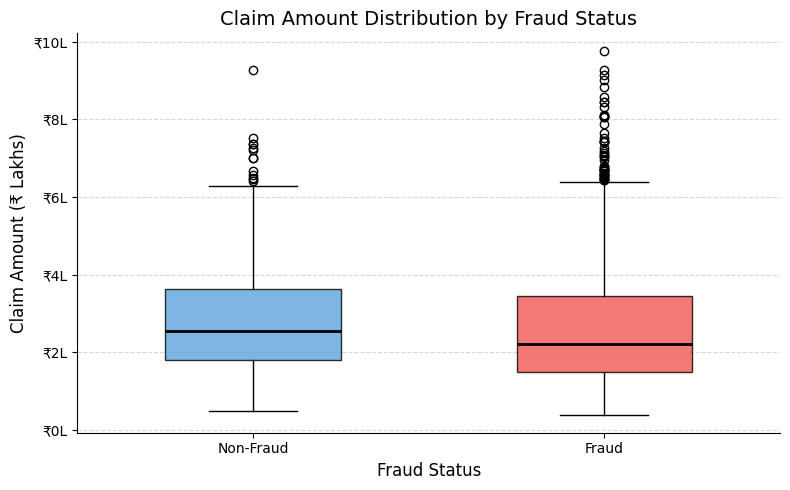

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# Data Preparation: Ensure claim amount is clean and usable for analysis
df['Claim_Amount'] = pd.to_numeric(df['Claim_Amount'], errors='coerce')
df = df.dropna(subset=['Claim_Amount'])

# Re-segmentation after fraud logic updates
fraud_df = df[df['Final_Fraud_Flag'] == True]
non_fraud_df = df[df['Final_Fraud_Flag'] == False]

plt.figure(figsize=(8,5))

box = plt.boxplot(
    [non_fraud_df['Claim_Amount'], fraud_df['Claim_Amount']],
    labels=['Non-Fraud', 'Fraud'],
    patch_artist=True,
    widths=0.5
)

# Visual Encoding: Distinguish fraud vs non-fraud using contrasting colors
colors = ['#5DA5DA', '#F15854']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

# Highlight median differences clearly for comparison
for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(2)

plt.title('Claim Amount Distribution by Fraud Status', fontsize=14)
plt.xlabel('Fraud Status', fontsize=12)
plt.ylabel('Claim Amount (₹ Lakhs)', fontsize=12)

# Improve readability: Avoid scientific notation for financial interpretation
plt.ticklabel_format(style='plain', axis='y')

# Format values in Lakhs for business clarity
plt.gca().yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'₹{x/100000:.0f}L')
)

# Subtle grid for easier comparison
plt.grid(axis='y', linestyle='--', alpha=0.5)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** Fraud cases exhibit a wider distribution and a higher concentration of extreme outliers compared to non-fraud cases. While median claim amounts remain comparable, fraudulent claims extend more frequently into higher ranges (₹7L+), indicating that unusually large claim values are a strong indicator of potential fraud risk.

***Chart 4: Correlation Analysis of Key Features Influencing Fraud Risk***

**Goal:** Identify relationships between numerical features and detect which variables are strongly associated with fraud behavior.

**Chart Type:** Heatmap (Correlation Matrix)

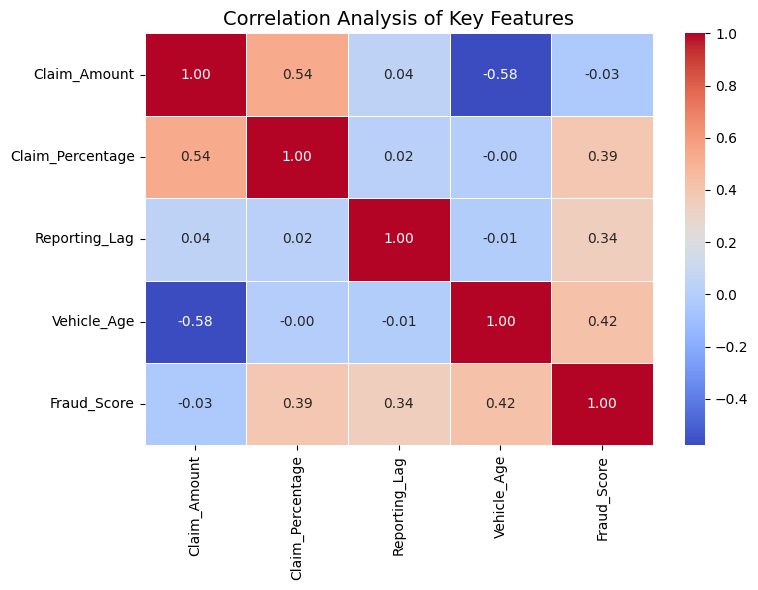

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Analysis: Identify relationships between key fraud-related variables
corr_cols = [
    'Claim_Amount',
    'Claim_Percentage',
    'Reporting_Lag',
    'Vehicle_Age',
    'Fraud_Score'
]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Analysis of Key Features', fontsize=14)

plt.tight_layout()
plt.show()

**Insight:** Claim Amount and Claim Percentage show a moderate positive correlation, indicating higher claim values tend to represent a larger proportion of insured value. Vehicle Age shows a negative correlation with Claim Amount, suggesting older vehicles tend to have lower claim values. Fraud Score exhibits moderate relationships with multiple features, reinforcing that fraud detection is driven by a combination of factors rather than a single variable.

***Chart 5: Fraud Risk Segmentation: Distribution of Claims Across Risk Levels***

**Goal:** Segment claims into Low, Medium, and High risk categories based on fraud score to identify where fraud is concentrated.

**Chart Type:** Bar Chart (Count Plot with Fraud Split)

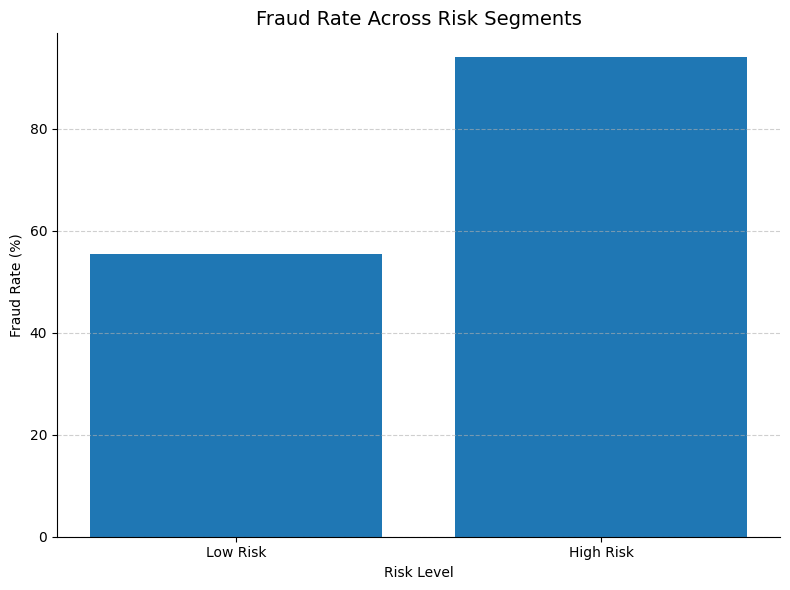

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Risk Segmentation: Categorize claims based on fraud score intensity
df['Risk_Level'] = pd.qcut(
    df['Fraud_Score'],
    q=3,
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Fraud Rate Analysis: Measure percentage of fraudulent claims within each risk segment
risk_summary = df.groupby('Risk_Level')['Final_Fraud_Flag'].mean().reset_index()
risk_summary['Fraud_Percentage'] = risk_summary['Final_Fraud_Flag'] * 100


plt.figure(figsize=(8,6))

plt.bar(risk_summary['Risk_Level'], risk_summary['Fraud_Percentage'])

plt.title('Fraud Rate Across Risk Segments', fontsize=14)
plt.xlabel('Risk Level')
plt.ylabel('Fraud Rate (%)')

# Visual clarity: Highlight trend differences across segments
plt.grid(axis='y', linestyle='--', alpha=0.6)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Insight:** Fraud rates increase significantly across risk segments, with high-risk claims showing a substantially higher likelihood of fraud compared to low-risk claims. However, the presence of fraud in lower-risk segments indicates that risk scoring is probabilistic rather than definitive, reflecting real-world uncertainty.

### 7. Final Summary & Recommendations

***Key Insights***

**1. Fraud likelihood increases with risk segmentation**
Claims categorized under higher risk levels show significantly higher fraud rates compared to low-risk segments. This validates the effectiveness of the fraud scoring logic in identifying suspicious patterns.

**2. Fraud and non-fraud claim distributions overlap**
While fraud cases tend to have slightly higher claim amounts, there is considerable overlap between fraud and non-fraud distributions. This indicates that claim amount alone is not a reliable indicator of fraud and must be combined with other features.

**3. Fraud cases exhibit higher variability and outliers**
Box plot analysis reveals that fraudulent claims have more extreme values and wider spread. This suggests that fraud often involves unusually high or inconsistent claim behavior.

**4. No single feature strongly predicts fraud**
Correlation analysis shows moderate relationships between features and fraud score, but no single variable dominates. Fraud detection requires a combination of multiple indicators rather than reliance on one factor.

***Business Recommendation***

A rule-based fraud detection system should incorporate multiple signals such as claim amount ratio, reporting delay, claim frequency, and contextual factors (e.g., vehicle age, claim cause). Relying on a single metric can lead to misclassification and missed fraud cases.

***Analytical Note***

To better simulate real-world conditions, controlled noise was introduced into the fraud labels. This ensures that the model reflects practical uncertainty, where fraud patterns are not perfectly deterministic.

--------------------------------------------------------------------------------------------------------------------------------------


**Project Details**

**Project Created by:** Akshaya V.S.

**Date:** 2025 - 2026

**Tools Used:** Python (Pandas, Matplotlib, Seaborn), Jupyter Notebook